# ML-10 — Content Action Playbook

**Lane:** CTR opportunity scoring. This is an offline, non-production editorial review plan, prepared with AI assistance. It continues the validation-selected **training-only position/content-type peer rule** from ML-08 and the limits established in ML-09. It does not deploy the forest or change the objective to decline classification.

**Decision:** review a positive contextual CTR gap, establish whether an edit is appropriate, then let the authorized editor decide. The score is a click-equivalent priority proxy, not expected recovered clicks or monetary value. Independent editorial precision@20, future performance and refresh effects remain unmeasured.

Run with Python 3.11: `pip install -r work/requirements-w05.txt`, then `python work/scripts/run_w07_action_playbook.py`, or Run All from this starter directory. The runner uses the current interpreter. In this GitHub repository the starter is nested under `flyrank-ml-internship-starter-main/`. Queue CSVs regenerate into `work/outputs/` and stay ignored; aggregate JSON receipts and reusable figures are committed.

## 1. Ranked actions + reason codes

### Reproduce the validated output before adding an action

Use the frozen seed-42 disjoint-client 16/6/6 train/validation/test split from Week 5. Eligibility stays at ≥500 impressions and recorded average position 1–20; zero position is missing, not rank zero. A benchmark requires ≥30 **training** peer pages and ≥3 training clients in the same position band/content type. Only training clicks and impressions determine pooled peer CTR. This playbook uses the supported **held-out test queue**, not an in-sample fit over every page.

The queue sorts `impressions_90d × max(peer_CTR_pct − observed_CTR_pct, 0) / 100`, then impressions descending and original row ascending. There is no new fitted model or retrospective threshold search. CTR is computed from counts in percent; gaps and errors are percentage points (pp). IDs support joins and group separation only. Additional 30-day counts and update age are **current-snapshot action context**, never estimator inputs, ranking factors, future labels or evaluation truth.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import GroupShuffleSplit
from IPython.display import display, Markdown

SEED, K, CLIENT_CAP = 42, 20, 5
MIN_IMPRESSIONS, MIN_PEER_PAGES, MIN_PEER_CLIENTS = 500, 30, 3
POSITION_EDGES, POSITION_LABELS = [0, 3, 10, 20], ["1-3", ">3-10", ">10-20"]
GROUP_KEYS = ["content_id", "client_id"]
SCORE_INPUTS = ["impressions_90d", "clicks_90d", "avg_position", "content_type"]
ACTION_CONTEXT = ["days_since_last_update", "impressions_prev_30d", "impressions_last_30d"]
relative_csv = Path("data/raw/content_refresh_anonymized.csv")
root = next((candidate for base in (Path.cwd(), *Path.cwd().parents)
             for candidate in (base, base / "flyrank-ml-internship-starter-main")
             if (candidate / relative_csv).is_file()), None)
if root is None:
    raise FileNotFoundError("Run inside the starter clone with its approved CSV.")
outputs, figures = root / "work/outputs", root / "work/figures"
outputs.mkdir(parents=True, exist_ok=True)
figures.mkdir(parents=True, exist_ok=True)
source = root / relative_csv
data_hash = hashlib.sha256(source.read_bytes()).hexdigest()
w05_path = outputs / "w05_model_metrics.json"
w06_path = outputs / "w06_validation_audit_metrics.json"
w05, w06 = json.loads(w05_path.read_text()), json.loads(w06_path.read_text())
assert data_hash == w05["data_sha256"] == w06["data_sha256"]
assert w05["selected_on_validation"] == w06["original_selection"] == "Week-4 peer rule (train-only)"
df = pd.read_csv(source, usecols=GROUP_KEYS + SCORE_INPUTS + ACTION_CONTEXT)
assert df.shape == (30000, 9) and df["client_id"].nunique() == 32
assert df.notna().all().all() and df["content_id"].is_unique
count_cols = ["impressions_90d", "clicks_90d", "impressions_prev_30d", "impressions_last_30d"]
assert df[count_cols].ge(0).all().all()
assert df["impressions_90d"].gt(0).all() and df["clicks_90d"].le(df["impressions_90d"]).all()
assert df["days_since_last_update"].ge(0).all()
lane = df.loc[df["impressions_90d"].ge(MIN_IMPRESSIONS) & df["avg_position"].between(1, 20)].copy()
lane["source_row"] = lane.index
lane["observed_ctr_pct"] = 100 * lane["clicks_90d"] / lane["impressions_90d"]
lane["position_band"] = pd.cut(lane["avg_position"], POSITION_EDGES, labels=POSITION_LABELS)
assert len(lane) == 12009
outer = GroupShuffleSplit(n_splits=1, test_size=.20, random_state=SEED)
dev_idx, test_idx = next(outer.split(lane, groups=lane["client_id"]))
dev, test = lane.iloc[dev_idx].copy(), lane.iloc[test_idx].copy()
inner = GroupShuffleSplit(n_splits=1, test_size=.25, random_state=SEED)
train_idx, val_idx = next(inner.split(dev, groups=dev["client_id"]))
train, validation = dev.iloc[train_idx].copy(), dev.iloc[val_idx].copy()
parts = {"train": train, "validation": validation, "test": test}
groups = {name: set(part["client_id"]) for name, part in parts.items()}
assert not (groups["train"] & groups["validation"] or groups["train"] & groups["test"] or groups["validation"] & groups["test"])
assert [len(groups[name]) for name in parts] == [16, 6, 6]
peer_keys = ["position_band", "content_type"]
peers = train.groupby(peer_keys, observed=True).agg(
    peer_pages=("content_id", "size"), peer_clients=("client_id", "nunique"),
    peer_impressions=("impressions_90d", "sum"), peer_clicks=("clicks_90d", "sum"))
peers["peer_ctr_pct"] = 100 * peers["peer_clicks"] / peers["peer_impressions"]
test = test.join(peers, on=peer_keys, validate="many_to_one")
test["supported"] = test["peer_pages"].ge(MIN_PEER_PAGES) & test["peer_clients"].ge(MIN_PEER_CLIENTS) & test["peer_impressions"].gt(0)
test["peer_ctr_pct"] = test["peer_ctr_pct"].where(test["supported"])
scored = test.loc[test["supported"]].copy()
assert len(scored) == 760
scored["ctr_gap_pp"] = (scored["peer_ctr_pct"] - scored["observed_ctr_pct"]).clip(lower=0)
scored["priority_proxy"] = scored["impressions_90d"] * scored["ctr_gap_pp"] / 100
queue = scored.loc[scored["priority_proxy"].gt(0)].sort_values(
    ["priority_proxy", "impressions_90d", "source_row"], ascending=[False, False, True], kind="stable").copy()
queue["canonical_rank"] = np.arange(1, len(queue) + 1)
peer_test_mae = float(np.average((scored["peer_ctr_pct"] - scored["observed_ctr_pct"]).abs(), weights=scored["impressions_90d"]))
original = next(row for row in w05["test_metrics"] if row["method"] == w05["selected_on_validation"])
assert np.isclose(peer_test_mae, original["weighted_MAE_pp"], atol=1e-9, rtol=0)
split_table = pd.DataFrame([{"partition": name, "pages": len(part), "clients": len(groups[name])} for name, part in parts.items()])
display(split_table)
print(f"Same supported test pool: {len(scored)} pages; peer weighted MAE {peer_test_mae:.6f} pp.")
print(f"{len(queue)} positive-gap candidates; {int((~test['supported']).sum())} test pages deferred for peer support.")
print("No independent editorial labels: precision@20 and editorial base rate unavailable.")

,partition,pages,clients
0,train,6519,16
1,validation,4669,6
2,test,821,6


Same supported test pool: 760 pages; peer weighted MAE 0.383436 pp.
493 positive-gap candidates; 61 test pages deferred for peer support.
No independent editorial labels: precision@20 and editorial base rate unavailable.


### Archetype → action mapping

Each positive-gap candidate has the primary reason `below_position_type_peer_ctr`. The following action branches are **editorial policy assumptions**, not learned effects. They are mutually exclusive, evaluated top to bottom, and preserve canonical score/rank.

| First matching archetype | Added reason | First action | What can invalidate it |
|---|---|---|---|
| Updated ≤30 days ago | `recent_update_observe` | Wait for a separate complete post-edit window; inspect measurement now | The snapshot overlaps the edit; no edit date or forward outcome is available |
| Updated ≥181 days ago, previous 30d ≥100 impressions, recent 30d <80% of previous | `stale_and_observed_decline` | Investigate decay and factual freshness before proposing a targeted refresh | Seasonality, topic/query mix, indexing or visibility could explain the decline |
| Position 1–3 | `top_visibility_low_capture` | Review snippet, intent and search-result context | Branded/non-branded demand, device mix or SERP features may explain low capture |
| Position >3–10 | `page_one_low_capture` | Review snippet/intent against matched search contexts | Broad average position hides query differences; the peer pool may be inappropriate |
| Position >10–20 | `striking_distance_low_capture` | Review query coverage, intent and internal linking first | Limited visibility may dominate; a snippet rewrite alone may be irrelevant |

**Decay/refresh insight:** old update age plus an observed exposure decline is an investigation flag, not evidence of content decay or a refresh treatment effect. Age alone never triggers a refresh. This analysis uses recent/previous impressions as action context only; it does not reuse `trend_pct`, `trend_direction` or the derived decline label. A small/zero previous denominator is marked unassessable rather than given an infinite decline ratio. Recent edits enter observation, not a repeated-refresh loop. The measured freshness permutation result from ML-09 follows below; it provides no positive predictive contribution in that run.

In [2]:
STALE_DAYS, RECENT_DAYS, MIN_PREV30 = 181, 30, 100
queue["trend_assessable"] = queue["impressions_prev_30d"].ge(MIN_PREV30)
queue["recent_impression_change_pct"] = (100 * (queue["impressions_last_30d"] / queue["impressions_prev_30d"].replace(0, np.nan) - 1)).where(queue["trend_assessable"])
queue["decline_context"] = queue["trend_assessable"] & queue["recent_impression_change_pct"].lt(-20)
queue["stale_context"] = queue["days_since_last_update"].ge(STALE_DAYS)
recent = queue["days_since_last_update"].le(RECENT_DAYS)
stale_decline = queue["stale_context"] & queue["decline_context"]
queue["archetype"] = np.select(
    [recent, stale_decline, queue["avg_position"].le(3), queue["avg_position"].le(10)],
    ["recent_update_observe", "stale_and_observed_decline", "top_visibility_low_capture", "page_one_low_capture"],
    default="striking_distance_low_capture")
action_map = {
    "recent_update_observe": "observe_post_edit_window",
    "stale_and_observed_decline": "investigate_decay_then_review_refresh",
    "top_visibility_low_capture": "review_snippet_intent_and_serp",
    "page_one_low_capture": "review_snippet_and_intent",
    "striking_distance_low_capture": "review_coverage_intent_and_internal_links",
}
queue["action"] = queue["archetype"].map(action_map)
queue["reason_codes"] = "below_position_type_peer_ctr;" + queue["archetype"]
queue.loc[~queue["trend_assessable"], "reason_codes"] += ";trend_denominator_insufficient"
queue["review_status"] = "draft_requires_human_review"
queue["automated_edit_allowed"] = False
queue["priority_confidence"] = "unvalidated_editorial_proxy"
# This batch is an explicit capacity policy, not the original ranked top-20 metric.
queue["client_queue_order"] = queue.groupby("client_id", sort=False).cumcount() + 1
batch = queue.loc[queue["client_queue_order"].le(CLIENT_CAP)].head(K).copy()
batch["review_slot"] = np.arange(1, len(batch) + 1)
raw_top = queue.head(K)
def concentration(part):
    counts = part["client_id"].value_counts()
    return float(counts.max() / len(part)) if len(part) else 0.0
batch_diagnostics = pd.DataFrame([
    {"queue": name, "filled_slots": len(part), "clients": part["client_id"].nunique(),
     "largest_client_slot_share": concentration(part), "editorial_precision": "unavailable"}
    for name, part in [("canonical top-20", raw_top), ("review batch: max 5/client", batch)]])
display(batch_diagnostics)
# Keep linking IDs in the ignored CSV; the public notebook displays only local case ranks and context.
preview_cols = ["canonical_rank", "position_band", "observed_ctr_pct", "peer_ctr_pct", "priority_proxy", "archetype", "action", "review_status"]
display(queue.head(10)[preview_cols].reset_index(drop=True).round(3))
archetype_summary = queue.groupby("archetype", observed=True).agg(
    pages=("content_id", "size"), clients=("client_id", "nunique"),
    median_priority_proxy=("priority_proxy", "median")).reset_index()
display(archetype_summary.round(2))
decay_summary = pd.DataFrame([
    {"context": "all positive-gap candidates", "pages": len(queue)},
    {"context": "trend denominator assessable (previous >=100)", "pages": int(queue["trend_assessable"].sum())},
    {"context": "observed >20% impression decline", "pages": int(queue["decline_context"].sum())},
    {"context": "stale and observed decline (before recent-update precedence)", "pages": int(stale_decline.sum())},
    {"context": "recent update: observe", "pages": int(recent.sum())},
])
display(decay_summary)
freshness_evidence = next(row for row in w06["original_holdout_permutation_importance"] if row["feature"] == "days_since_last_update")
print(f"ML-09 freshness shuffling: weighted-MAE change {freshness_evidence['increase_weighted_MAE_pp']:+.6f} pp; shuffle SD {freshness_evidence['shuffle_SD_pp']:.6f} pp.")
print("No positive predictive contribution demonstrated here; no refresh effect measured.")

,queue,filled_slots,clients,largest_client_slot_share,editorial_precision
0,canonical top-20,20,2,0.95,unavailable
1,review batch: max 5/client,20,6,0.25,unavailable


,canonical_rank,position_band,observed_ctr_pct,peer_ctr_pct,priority_proxy,archetype,action,review_status
0,1,>10-20,0.152,0.367,132.588,stale_and_observed_decline,investigate_decay_then_review_refresh,draft_requires_human_review
1,2,>3-10,0.204,0.378,128.999,recent_update_observe,observe_post_edit_window,draft_requires_human_review
2,3,>10-20,0.133,0.367,105.784,recent_update_observe,observe_post_edit_window,draft_requires_human_review
3,4,>3-10,0.122,0.378,103.354,recent_update_observe,observe_post_edit_window,draft_requires_human_review
4,5,>3-10,0.178,0.378,98.716,recent_update_observe,observe_post_edit_window,draft_requires_human_review
5,6,>3-10,0.146,0.378,85.631,recent_update_observe,observe_post_edit_window,draft_requires_human_review
6,7,>3-10,0.004,0.378,83.907,recent_update_observe,observe_post_edit_window,draft_requires_human_review
7,8,>3-10,0.009,0.378,82.790,recent_update_observe,observe_post_edit_window,draft_requires_human_review
8,9,>10-20,0.088,0.367,72.513,recent_update_observe,observe_post_edit_window,draft_requires_human_review
9,10,>3-10,0.034,0.378,69.846,recent_update_observe,observe_post_edit_window,draft_requires_human_review


,archetype,pages,clients,median_priority_proxy
0,page_one_low_capture,30,2,4.30
1,recent_update_observe,423,5,4.21
2,stale_and_observed_decline,6,2,2.99
3,striking_distance_low_capture,33,4,3.78
4,top_visibility_low_capture,1,1,3.45


,context,pages
0,all positive-gap candidates,493
1,trend denominator assessable (previous >=100),469
2,observed >20% impression decline,425
3,stale and observed decline (before recent-upda...,6
4,recent update: observe,423


ML-09 freshness shuffling: weighted-MAE change -0.004100 pp; shuffle SD 0.002967 pp.
No positive predictive contribution demonstrated here; no refresh effect measured.


**Observed queue, not an intervention result:** 493 of the 760 supported test pages have a positive gap; 267 do not. A further 61 test pages abstain for insufficient peer support. Of the candidates, 423 were updated within 30 days, so the first recommendation for most is to inspect measurement and observe a separate post-edit window. Only 6 satisfy the stale-plus-decline policy. The top-position action bucket has **n=1** and cannot support a general segment conclusion.

Canonical top-20 has 19 slots from one client (95%). The explicit five-per-client capacity policy fills 20 slots across six clients, with a maximum share of 25%. That is a change in allocation, not evidence of better editorial precision. Keep both files so the paper can distinguish the frozen ranking from the review workflow.

## 2. Intended use and limits

**User and decision:** an authorized content editor/analyst uses up to 20 triage slots per cycle to investigate the held-out starter cohort. The CSV's pseudonymous IDs let a reviewer join approved records locally; the dataset itself contains no snippet text, URL, query or brand context. This is a practical offline proposal, not a production-ready recommendation service. Any actual edits need separately authorized access and editorial approval.

**Evidence boundary:** Week 5 measured current-snapshot CTR estimation on 760 supported pages from six unseen test clients. Week 6 broadened coverage to grouped OOF over previously inspected clients. That audit's naive pooled-CTR reference had lower weighted error than both the peer rule and forest: the peer policy is retained for transparency/continuity, not claimed optimal. Error on CTR does not validate actionability or intervention value. Broad peer bands, client exposure concentration, pooled query/device mix, selection bias and overlapping windows remain limitations. A capacity cap changes review allocation, not predictive accuracy or fairness validation. Unsupported content types and cohorts abstain; silence is not a healthy-page verdict.

**Cost/value:** start with 15 minutes of triage per slot. Budget up to four approved pilots at two hours each, including editing and QA; with 20 slots that is 13 hours. These are planning assumptions, not measured timings. An owner sets the labor rate, conversion margin and allowable effort. Do not translate the priority proxy into revenue. If eligible value per additional *attributable* click were $v, the batch needs `labor_cost / v` incremental clicks to break even; neither v nor incremental clicks is observed here. Actual benefit can be zero or negative. For the observe branch, reserve effort for measurement rather than a rewrite. Log actual time and expand only after evidence supports value.

In [3]:
audit_table = pd.DataFrame(w06["oof_comparison"])
display(audit_table.loc[audit_table["protocol"].eq("grouped client OOF (honest)"),
    ["method", "pages", "clients", "weighted_MAE_pp", "equal_client_MAE_pp"]].round(6))
print("Grouped audit reuses inspected clients; this is robustness evidence, not a fresh final test.")
TRIAGE_MINUTES, MAX_PILOTS, PILOT_HOURS = 15, 4, 2
pilot_candidates = int(batch["action"].ne("observe_post_edit_window").sum())
pilot_slots = min(MAX_PILOTS, pilot_candidates)
triage_hours = len(batch) * TRIAGE_MINUTES / 60
budget_hours = triage_hours + pilot_slots * PILOT_HOURS
cost_rows = []
for hourly_cost in [15, 30, 60]:
    for value_per_incremental_click in [.10, .50, 1.00]:
        labor_cost = budget_hours * hourly_cost
        cost_rows.append({"assumed_labor_USD_per_hour": hourly_cost,
            "planned_hours": budget_hours, "labor_cost_USD": labor_cost,
            "assumed_USD_per_attributable_click": value_per_incremental_click,
            "break_even_incremental_clicks": int(np.ceil(labor_cost / value_per_incremental_click))})
cost_table = pd.DataFrame(cost_rows)
display(cost_table)
print(f"Current batch: {len(batch)} triage slots ({triage_hours:.2f}h), up to {pilot_slots} approved pilots; budget {budget_hours:.2f}h.")
print("USD amounts are illustrative assumptions, not client economics; expected benefit is unknown.")

,method,pages,clients,weighted_MAE_pp,equal_client_MAE_pp
3,naive training pooled CTR,11911,28,0.250899,0.411826
4,training-only peer rule,11911,28,0.258531,0.412685
5,frozen Week-5 forest,11911,28,0.264557,0.408535


Grouped audit reuses inspected clients; this is robustness evidence, not a fresh final test.


,assumed_labor_USD_per_hour,planned_hours,labor_cost_USD,assumed_USD_per_attributable_click,break_even_incremental_clicks
0,15,13.0,195.0,0.1,1950
1,15,13.0,195.0,0.5,390
2,15,13.0,195.0,1.0,195
3,30,13.0,390.0,0.1,3900
4,30,13.0,390.0,0.5,780
5,30,13.0,390.0,1.0,390
6,60,13.0,780.0,0.1,7800
7,60,13.0,780.0,0.5,1560
8,60,13.0,780.0,1.0,780


Current batch: 20 triage slots (5.00h), up to 4 approved pilots; budget 13.00h.
USD amounts are illustrative assumptions, not client economics; expected benefit is unknown.


## 3. Human review + the no-go list

**Approval flow:** `draft → measurement/context check → accept / reject / defer → owner-approved pilot → QA → observe → retain / rollback`. Automation may prepare the queue, reason flags and aggregate monitors. Every exported candidate remains **draft**; no check in this notebook grants editing permission.

1. Analyst checks source/window completeness, counts, position sentinel, cohort support and whether the peer mix is appropriate. Confirm update date and query/device/SERP context in an approved system. Reject measurement artifacts; defer insufficient context.
2. Editor inspects the actual page, snippet, intent and factual accuracy. For stale/declining pages, first investigate seasonality, indexing and visibility. For recently updated pages, wait for a complete non-overlapping observation window. Reject cases whose low CTR is explained by context.
3. Owner records accept/reject/defer, reason, estimated effort, expected objective and reviewer identity **privately**. Cap pilot effort, choose a reversible change, save the prior version, and have a second reviewer QA factual accuracy and brand requirements. No client identity, page text or private queries enter GitHub.
4. To evaluate ranking usefulness, obtain blinded independent `review_worth_action` judgments for all available batch slots and a comparably sampled control queue. Use the same supported pool/budget for peer, naive and impressions-only comparisons; do not use decline labels or this rule as truth. Report numerator/denominator, base rate, client mix and uncertainty; the capped batch is not canonical precision@20. For causal effects use a prospectively designed randomized pilot with separate windows, controls and client-aware analysis; simple selected-page before/after comparisons remain confounded.

**Never automate:** publishing or rewriting snippets/content; refreshing merely because age exceeds a cutoff; repeated edits from overlapping-window signals; deletion, redirects, canonical/indexing changes, link building or bulk generation; factual/medical/legal claims; client budget allocation or ROI promises; approval/reviewer labels; filling absent position/trend data as healthy; interpreting AI referral traffic as citations; retraining/promotion from a drift alert alone. These actions need human decisions or are outside this playbook. No sensitive/high-stakes content or new client cohort enters a pilot without specialist/owner review. Data-quality failure pauses review exports, not just model scoring.

The review template below is a **blank local schema**, not completed human review. Independent judgments and post-edit outcomes do not exist yet.

In [4]:
review_fields = [
    ("canonical_rank", "join to local draft queue"),
    ("measurement_check", "pending / pass / fail; analyst and window note"),
    ("context_check", "pending / pass / defer; query/device/intent explanation"),
    ("editor_decision", "pending / accept / reject / defer; independent rationale"),
    ("estimated_effort_hours", "human estimate; absent until reviewed"),
    ("owner_approval", "pending / approve / decline; required before any edit"),
    ("qa_and_rollback_plan", "saved prior version, factual/brand review, restoration steps"),
    ("outcome_window_and_controls", "prospective separate windows; no causal inference by default"),
]
display(pd.DataFrame(review_fields, columns=["field", "required_meaning"]))
review_template = batch[["review_slot", "canonical_rank", "content_id", "client_id", "action"]].copy()
for field in ["measurement_check", "context_check", "editor_decision", "owner_approval"]:
    review_template[field] = "pending"
for field in ["estimated_effort_hours", "reviewer", "decision_reason", "qa_and_rollback_plan", "outcome_window_and_controls"]:
    review_template[field] = ""
assert queue["review_status"].eq("draft_requires_human_review").all()
assert not queue["automated_edit_allowed"].any()
assert review_template["owner_approval"].eq("pending").all()
print("All candidates are unreviewed drafts; zero editorial decisions or edits performed.")

,field,required_meaning
0,canonical_rank,join to local draft queue
1,measurement_check,pending / pass / fail; analyst and window note
2,context_check,pending / pass / defer; query/device/intent ex...
3,editor_decision,pending / accept / reject / defer; independent...
4,estimated_effort_hours,human estimate; absent until reviewed
5,owner_approval,pending / approve / decline; required before a...
6,qa_and_rollback_plan,"saved prior version, factual/brand review, res..."
7,outcome_window_and_controls,prospective separate windows; no causal infere...


All candidates are unreviewed drafts; zero editorial decisions or edits performed.


## 4. Monitoring / retrain triggers

These thresholds are proposed operating rules, not empirically optimized alarms. The starter snapshot has no trustworthy export timestamp or live history, so freshness/ongoing drift cannot be assessed today. The only live result here is the initial baseline. Review owner runs checks per new approved export; weekly review is a proposed cadence once such exports exist. Do not poll/retrain on the same frozen CSV.

| Check / owner | Proposed trigger | Response |
|---|---|---|
| Schema, grain, counts / analyst, each export | Missing required input, duplicate content ID, negative counts, impossible clicks, non-finite rates | Stop; repair source and rerun; never auto-fill |
| Freshness / analyst, each cycle | Missing source timestamp or export >30 days old | Mark freshness unknown/stale; obtain complete current windows before operational use |
| Eligible-pool coverage / analyst | Supported share falls >5 pp versus baseline, or total eligible pages changes >25% | Investigate source, client/type mix and peer support; keep abstentions |
| Input mix / analyst | Position-band or content-type total-variation distance >0.20 for two complete exports | Investigate new clients/mix; rebuild peer tables only after approval |
| Allocation / editor, each batch | Canonical top-20 client share >50%, or >5 rows/client in capped batch | Inspect concentration; enforce cap; leave slots empty if needed |
| Editorial utility / editor | Once ≥100 independently reviewed cases exist across ≥5 clients, reviewed actionability drops >10 pp versus a prior comparable approved review cycle, or fails to beat the same-budget control | Pause expansion; inspect label reliability and context; gather evidence. Unknown/too-small samples stay unknown |
| Surrogate error / analyst, new labels | Weighted CTR MAE increases >25% on a comparable client-disjoint new-window pool, for two cycles | Investigate drift and window quality; consider rebuilding peers/retraining as a separate experiment |
| Pilot quality / owner, each pilot | Factual error, broken measurement or editorial harm | Pause the pilot and restore the saved version with owner review |

**Retrain/promotion gate:** the current selected method is a peer rule, so rebuild its reference cohorts first when justified. Train a forest only as a challenger after investigating data quality/drift and collecting new context/outcomes. Fit all preprocessing within training clients; freeze the decision before a separate later-window/client test. Promotion needs both honest surrogate comparison including a naive reference **and independent same-budget editorial utility**; an error improvement or alert alone is insufficient. No trigger automatically publishes, refreshes or deploys a model.

In [5]:
def mix(part, column):
    return {str(key): float(value) for key, value in part[column].value_counts(normalize=True).items()}
monitor_baseline = {
    "eligible_test_pages": len(test),
    "supported_share": float(test["supported"].mean()),
    "position_mix": mix(test, "position_band"),
    "type_mix": mix(test, "content_type"),
    "peer_weighted_MAE_pp": peer_test_mae,
    "canonical_top20_max_client_share": concentration(raw_top),
    "source_export_timestamp": None,
    "independent_review_count": 0,
    "editorial_actionability": None,
}

def compare_monitor(current, reference):
    alerts = []
    if current["source_export_timestamp"] is None:
        alerts.append("FRESHNESS_UNKNOWN: source timestamp required before operational use")
    if reference["supported_share"] - current["supported_share"] > .05:
        alerts.append("COVERAGE_DROP: investigate support and source")
    if abs(current["eligible_test_pages"] / reference["eligible_test_pages"] - 1) > .25:
        alerts.append("VOLUME_SHIFT: investigate client and source coverage")
    for key in ["position_mix", "type_mix"]:
        levels = set(current[key]) | set(reference[key])
        tv = .5 * sum(abs(current[key].get(x, 0) - reference[key].get(x, 0)) for x in levels)
        if tv > .20:
            alerts.append(f"{key.upper()}_SHIFT: confirm on a second complete export")
    if current["canonical_top20_max_client_share"] > .50:
        alerts.append("CONCENTRATION: use capped human-review allocation")
    return alerts

initial_alerts = compare_monitor(monitor_baseline, monitor_baseline)
display(pd.DataFrame({"initial_baseline_check": initial_alerts}))
assert any(a.startswith("FRESHNESS_UNKNOWN") for a in initial_alerts)
assert not any("SHIFT" in a or "COVERAGE_DROP" in a for a in initial_alerts)
assert batch.groupby("client_id").size().le(CLIENT_CAP).all()
print("Same-snapshot self-comparison establishes a baseline, not observed temporal stability.")
print("Live drift, editorial utility, new-window error and retrain decisions: not assessed.")

,initial_baseline_check
0,FRESHNESS_UNKNOWN: source timestamp required b...
1,CONCENTRATION: use capped human-review allocation


Same-snapshot self-comparison establishes a baseline, not observed temporal stability.
Live drift, editorial utility, new-window error and retrain decisions: not assessed.


## 5. Exports for the paper

`work/outputs/w07_ranked_action_queue.csv` is the canonical positive-gap queue; `w07_review_batch.csv` is the explicitly capped review allocation; `w07_review_template.csv` is a blank pending-decision form. They contain only starter pseudonyms and approved context and are ignored by Git. Never commit them, completed private reviews or new datasets. Unsupported and nonpositive cases are accounted for in aggregate, not silently ranked.

`work/outputs/w07_action_playbook_metrics.json` records data/source-receipt hashes, reproduced validation evidence, coverage, action counts, costs and monitoring baseline. It contains no page/client identifiers or row-level queue. `w07_playbook_manifest.json` records export paths and hashes so the paper can verify exact regenerated inputs. Use the committed figures in `work/figures/` (also exported into `work/outputs/`): action archetype counts and canonical-versus-capped batch allocation. Counts are descriptive; charts carry no treatment effect claim.

**Paper-ready recommendation:** these starter-slice pages are worth human review because measured CTR is below a training-client position/type benchmark. Prioritize measurement and intent review, investigate old/declining cases, and observe recent edits before further changes. The queue is a directional decision-support proxy. We have not measured editorial precision, refresh benefit, future CTR or revenue; causal claims require a separate prospective design.

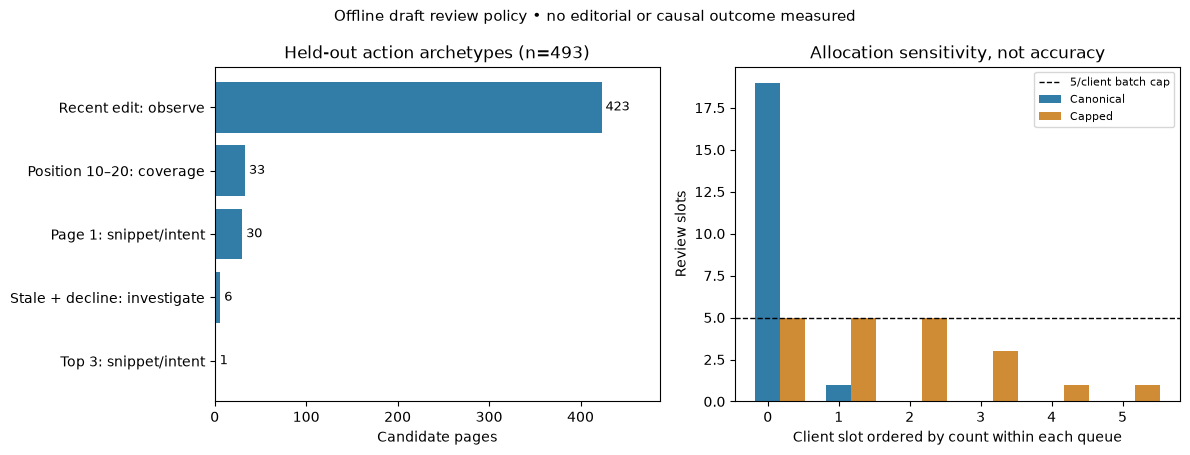

Exported canonical queue, review allocation, blank review form and reusable figure.


In [6]:
EXPORT_COLUMNS = ["canonical_rank", "content_id", "client_id", "position_band", "content_type",
    "impressions_90d", "clicks_90d", "observed_ctr_pct", "peer_ctr_pct", "ctr_gap_pp", "priority_proxy",
    "peer_pages", "peer_clients", "days_since_last_update", "impressions_prev_30d", "impressions_last_30d",
    "trend_assessable", "recent_impression_change_pct", "archetype", "action", "reason_codes",
    "priority_confidence", "review_status", "automated_edit_allowed"]
queue_path = outputs / "w07_ranked_action_queue.csv"
batch_path = outputs / "w07_review_batch.csv"
template_path = outputs / "w07_review_template.csv"
queue[EXPORT_COLUMNS].to_csv(queue_path, index=False)
batch[["review_slot"] + EXPORT_COLUMNS].to_csv(batch_path, index=False)
review_template.to_csv(template_path, index=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
labels = {"recent_update_observe": "Recent edit: observe", "stale_and_observed_decline": "Stale + decline: investigate",
          "top_visibility_low_capture": "Top 3: snippet/intent", "page_one_low_capture": "Page 1: snippet/intent",
          "striking_distance_low_capture": "Position 10–20: coverage"}
plot = archetype_summary.sort_values("pages")
axes[0].barh([labels[x] for x in plot["archetype"]], plot["pages"], color="#327ca8")
axes[0].set(xlabel="Candidate pages", title=f"Held-out action archetypes (n={len(queue)})", xlim=(0, plot["pages"].max() * 1.15))
for y, count in enumerate(plot["pages"]):
    axes[0].text(count, y, f" {count}", va="center", fontsize=9)
# Client labels are anonymous allocation slots, sorted separately within each queue.
for i, (name, part, color) in enumerate([("Canonical", raw_top, "#327ca8"), ("Capped", batch, "#d08c34")]):
    counts = part["client_id"].value_counts().to_numpy()
    axes[1].bar(np.arange(len(counts)) + i * .35, counts, width=.35, label=name, color=color)
axes[1].axhline(CLIENT_CAP, color="black", linestyle="--", linewidth=1, label="5/client batch cap")
axes[1].set(xlabel="Client slot ordered by count within each queue", ylabel="Review slots", title="Allocation sensitivity, not accuracy")
axes[1].set_xticks(range(max(raw_top["client_id"].nunique(), batch["client_id"].nunique())))
axes[1].legend(fontsize=8)
fig.suptitle("Offline draft review policy • no editorial or causal outcome measured", fontsize=11)
fig.tight_layout()
figure_paths = []
for folder in [outputs, figures]:
    path = folder / "w07_action_playbook.png"
    fig.savefig(path, dpi=160, bbox_inches="tight")
    figure_paths.append(path)
plt.show()
plt.close(fig)
print("Exported canonical queue, review allocation, blank review form and reusable figure.")

## 6. Self-check

The checks below enforce the evidence-to-action boundary: training-only peers; exact Week-5 held-out metric; distinct client groups; no outcome-derived trend inputs in score; deterministic positive ranks; complete action mapping; pending human decisions; client-cap enforcement; regenerated CSV round-trip; anonymous aggregate receipts and export integrity.

- [x] Intended use, limits, ranked actions, reason codes and archetype mapping are explicit.
- [x] Decay/refresh interpretation separates observed context from unsupported treatment claims.
- [x] Human review, approval, rollback and no-go actions are stated; zero edits are authorized by the queue.
- [x] Cost/value assumptions, monitoring thresholds and retrain/promotion gates are practical and provisional.
- [x] Queue exports remain local/ignored; paper receipts and figures are safe to commit.
- [x] Independent editorial precision, future performance, monetary value and refresh effects remain unavailable.

A successful Run All verifies notebook execution and local exports. GitHub publication and portal submission are verified separately after committing this notebook.

In [7]:
assert queue["content_id"].is_unique and queue["priority_proxy"].gt(0).all()
assert queue["priority_proxy"].is_monotonic_decreasing
assert queue["canonical_rank"].tolist() == list(range(1, len(queue) + 1))
assert queue["peer_pages"].ge(MIN_PEER_PAGES).all() and queue["peer_clients"].ge(MIN_PEER_CLIENTS).all()
assert queue["avg_position"].between(1, 20).all() and queue["impressions_90d"].ge(MIN_IMPRESSIONS).all()
assert queue["action"].notna().all() and queue["archetype"].isin(action_map).all()
assert queue["reason_codes"].str.startswith("below_position_type_peer_ctr;").all()
assert queue["review_status"].eq("draft_requires_human_review").all() and not queue["automated_edit_allowed"].any()
assert set(df.columns) == set(GROUP_KEYS + SCORE_INPUTS + ACTION_CONTEXT)
assert not set(SCORE_INPUTS).intersection(ACTION_CONTEXT + GROUP_KEYS + ["trend_pct", "trend_direction", "is_declining_label", "ctr"])
# Recompute ranking using score inputs only: action-context rules did not change scores.
expected = scored.loc[scored["priority_proxy"].gt(0)].sort_values(
    ["priority_proxy", "impressions_90d", "source_row"], ascending=[False, False, True], kind="stable")
assert queue.index.tolist() == expected.index.tolist()
assert len(test) == int((~test["supported"]).sum()) + len(scored)
assert len(scored) == len(queue) + int(scored["priority_proxy"].eq(0).sum())
assert batch.groupby("client_id").size().le(CLIENT_CAP).all() and len(batch) <= K
saved = pd.read_csv(queue_path)
assert saved["content_id"].tolist() == queue["content_id"].tolist()
assert saved["canonical_rank"].tolist() == queue["canonical_rank"].tolist()
assert np.allclose(saved["priority_proxy"], queue["priority_proxy"])
saved_batch = pd.read_csv(batch_path)
assert saved_batch["canonical_rank"].tolist() == batch["canonical_rank"].tolist()
assert pd.read_csv(template_path)["owner_approval"].eq("pending").all()

def records(table):
    return json.loads(table.to_json(orient="records", double_precision=10))

receipt = {
    "assignment": "ML-10", "scope": "offline held-out starter-slice CTR review playbook; non-production",
    "versions": {"python": platform.python_version(), "pandas": pd.__version__, "numpy": np.__version__,
                 "scikit_learn": sklearn.__version__},
    "data_sha256": data_hash, "seed": SEED,
    "source_receipts": {str(p.relative_to(root)): hashlib.sha256(p.read_bytes()).hexdigest() for p in [w05_path, w06_path]},
    "selected_method": w05["selected_on_validation"],
    "score_inputs": SCORE_INPUTS, "action_context_only": ACTION_CONTEXT,
    "policy": {"minimum_impressions": MIN_IMPRESSIONS, "position_edges": POSITION_EDGES,
        "minimum_training_peer_pages": MIN_PEER_PAGES, "minimum_training_peer_clients": MIN_PEER_CLIENTS,
        "review_budget": K, "client_cap": CLIENT_CAP, "stale_days": STALE_DAYS,
        "recent_update_days": RECENT_DAYS, "minimum_previous_30d_impressions": MIN_PREV30,
        "decline_threshold_pct": -20},
    "split": records(split_table), "test_supported_pages": len(scored),
    "test_deferred_pages": int((~test["supported"]).sum()), "test_nonpositive_gap_pages": int(scored["priority_proxy"].eq(0).sum()),
    "positive_gap_candidates": len(queue), "reproduced_peer_test_weighted_MAE_pp": peer_test_mae,
    "archetype_summary": records(archetype_summary), "decay_context_summary": records(decay_summary),
    "allocation": records(batch_diagnostics),
    "freshness_permutation_evidence": freshness_evidence,
    "cost_assumptions": {"triage_minutes_per_slot": TRIAGE_MINUTES, "maximum_pilots": MAX_PILOTS,
        "hours_per_pilot": PILOT_HOURS, "current_planned_hours": budget_hours, "actual_cost_or_value_measured": False},
    "cost_scenarios": records(cost_table),
    "monitoring_baseline": monitor_baseline, "initial_alerts": initial_alerts,
    "independent_editorial_labels": 0, "editorial_precision_at_20": None,
    "editorial_base_rate": None, "refresh_effect": None, "expected_recovered_clicks": None,
    "human_reviews_completed": 0, "edits_performed": 0, "automated_edits_allowed": False,
    "limitations": ["Concurrent windows", "Unknown source timestamp", "No temporal or causal validation",
                    "No independent editorial outcome", "Unsupported peers deferred", "Broad pooled peers and client concentration",
                    "OOF audit reuses inspected clients; naive CTR reference has lower grouped weighted MAE"],
    "verification": "training-only peer reconstruction, held-out metric, action mapping, capacity cap and export round-trips passed",
}
receipt_path = outputs / "w07_action_playbook_metrics.json"
receipt_path.write_text(json.dumps(receipt, indent=2, allow_nan=False) + "\n")
export_paths = [queue_path, batch_path, template_path, receipt_path] + figure_paths
manifest = {"assignment": "ML-10", "input_sha256": data_hash,
    "exports": [{"path": str(p.relative_to(root)), "sha256": hashlib.sha256(p.read_bytes()).hexdigest(),
                 "commit_policy": "ignored local queue" if p.suffix == ".csv" else "public aggregate receipt or figure"}
                for p in export_paths]}
(outputs / "w07_playbook_manifest.json").write_text(json.dumps(manifest, indent=2, allow_nan=False) + "\n")
assert all(p.is_file() and p.stat().st_size > 0 for p in export_paths)
print("PASS: all self-checks; aggregate receipts and export manifest saved. Queue regeneration is reproducible.")

PASS: all self-checks; aggregate receipts and export manifest saved. Queue regeneration is reproducible.
